# 🛒 E-Commerce Analytics Capstone — Brazilian Olist Dataset

**Author:** Ketan Chavda  
**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Tools:** Python · SQLite · Power BI  

---

## 📋 Table of Contents

1. [Phase 1 — Data Engineering](#phase1)
2. [Phase 2 — RFM + Customer Segmentation](#phase2)
3. [Phase 3 — Churn Prediction (XGBoost + SHAP)](#phase3)
4. [Phase 4 — CLV Forecasting](#phase4)
5. [Phase 5 — Market Basket Analysis](#phase5)

---

> **How to use this notebook:**  
> Run cells top to bottom. Each phase builds on the previous one.  
> Raw Olist CSVs must be placed in `same folder` before running.


---
## ⚙️ Global Setup — Libraries & Config

In [1]:
# ============================================================
# GLOBAL IMPORTS & CONFIGURATION
# ============================================================

# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_recall_curve)
from xgboost import XGBClassifier
import shap

# Market Basket
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

# SQL
import sqlite3

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

print('✅ All libraries loaded successfully')
print(f'   pandas {pd.__version__} | numpy {np.__version__}')

✅ All libraries loaded successfully
   pandas 2.3.3 | numpy 2.3.5


---
<a id='phase1'></a>
# 📦 Phase 1 — Data Engineering

**Goal:** Load all 9 Olist tables, merge them into a single analytical master table,  
perform data quality checks, and engineer features for downstream analysis.

**Input:** 9 raw CSV files in `../data/raw/`  
**Output:** `../data/master_table.csv`

In [2]:
# ── 1.1  LOAD ALL 9 RAW TABLES ──────────────────────────────

orders          = pd.read_csv('olist_orders_dataset.csv')
order_items     = pd.read_csv('olist_order_items_dataset.csv')
order_payments  = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews   = pd.read_csv('olist_order_reviews_dataset.csv')
customers       = pd.read_csv('olist_customers_dataset.csv')
products        = pd.read_csv('olist_products_dataset.csv')
sellers         = pd.read_csv('olist_sellers_dataset.csv')
geo             = pd.read_csv('olist_geolocation_dataset.csv')
category_transl = pd.read_csv('product_category_name_translation.csv')

tables = {
    'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'customers': customers, 'products': products,
    'sellers': sellers, 'geo': geo, 'category_transl': category_transl
}

print('✅ All 9 tables loaded\n')
print(f'{"Table":<20} {"Rows":>8} {"Cols":>6}')
print('-' * 38)
for name, df in tables.items():
    print(f'{name:<20} {df.shape[0]:>8,} {df.shape[1]:>6}')

✅ All 9 tables loaded

Table                    Rows   Cols
--------------------------------------
orders                 99,441      8
order_items           112,650      7
order_payments        103,886      5
order_reviews          99,224      7
customers              99,441      5
products               32,951      9
sellers                 3,095      4
geo                  1,000,163      5
category_transl            71      2


In [3]:
# ── 1.2  PARSE DATE COLUMNS ─────────────────────────────────

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

print('✅ Date columns parsed')
orders[date_cols].dtypes

✅ Date columns parsed


order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [4]:
# ── 1.3  BUILD MASTER TABLE (multi-table join) ───────────────
# Step 1 : orders + customers
df = orders.merge(customers, on='customer_id', how='left')

# Step 2 : + order_items aggregated per order
items_agg = order_items.groupby('order_id').agg(
    num_items        = ('order_item_id', 'count'),
    total_item_value = ('price', 'sum'),
    total_freight    = ('freight_value', 'sum'),
    num_sellers      = ('seller_id', 'nunique')
).reset_index()
df = df.merge(items_agg, on='order_id', how='left')

# Step 3 : + payments aggregated per order
pay_agg = order_payments.groupby('order_id').agg(
    total_payment        = ('payment_value', 'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type', lambda x: x.mode()[0])
).reset_index()
df = df.merge(pay_agg, on='order_id', how='left')

# Step 4 : + reviews (one per order — most recent)
reviews_clean = (order_reviews
                 .sort_values('review_answer_timestamp')
                 .drop_duplicates('order_id', keep='last'))
df = df.merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')

# Step 5 : + dominant product category per order
items_cat = order_items.merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
).merge(category_transl, on='product_category_name', how='left')

cat_per_order = (
    items_cat.groupby('order_id')['product_category_name_english']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan) 
    .reset_index()
    .rename(columns={'product_category_name_english': 'main_category'})
)
df = df.merge(cat_per_order, on='order_id', how='left')

print(f'✅ Master table shape: {df.shape}')
df.head(3)

✅ Master table shape: (99441, 21)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,num_items,total_item_value,total_freight,num_sellers,total_payment,payment_installments,payment_type,review_score,main_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,29.99,8.72,1.00,38.71,1.00,voucher,4.00,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,118.70,22.76,1.00,141.46,1.00,boleto,4.00,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,159.90,19.22,1.00,179.12,3.00,credit_card,5.00,auto


In [5]:
# ── 1.4  DATA QUALITY CHECK ──────────────────────────────────

print('=' * 50)
print('MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing': missing, 'Pct%': missing_pct})
print(quality_df[quality_df['Missing'] > 0].sort_values('Pct%', ascending=False))

print('\n' + '=' * 50)
print('ORDER STATUS DISTRIBUTION')
print('=' * 50)
print(df['order_status'].value_counts())

print('\n' + '=' * 50)
print('DATE RANGE')
print('=' * 50)
print(f"First order : {df['order_purchase_timestamp'].min()}")
print(f"Last order  : {df['order_purchase_timestamp'].max()}")
print(f"Total orders: {len(df):,}")

MISSING VALUES
                               Missing  Pct%
order_delivered_customer_date     2965  2.98
main_category                     2185  2.20
order_delivered_carrier_date      1783  1.79
num_items                          775  0.78
total_item_value                   775  0.78
total_freight                      775  0.78
num_sellers                        775  0.78
review_score                       768  0.77
order_approved_at                  160  0.16
total_payment                        1  0.00
payment_installments                 1  0.00
payment_type                         1  0.00

ORDER STATUS DISTRIBUTION
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

DATE RANGE
First order : 2016-09-04 21:15:19
Last order  : 2018-10-17 17:30:18
Total orders: 99,441


In [6]:
# ── 1.5  FILTER TO DELIVERED ORDERS ONLY ────────────────────

df_clean = df[
    (df['order_status'] == 'delivered') &
    (df['order_delivered_customer_date'].notna())
].copy()

print(f'✅ Delivered orders: {len(df_clean):,} of {len(df):,} total')
print(f'   Dropped         : {len(df) - len(df_clean):,} rows')

✅ Delivered orders: 96,470 of 99,441 total
   Dropped         : 2,971 rows


In [7]:
# ── 1.6  FEATURE ENGINEERING ────────────────────────────────

# Delivery time features
df_clean['delivery_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_purchase_timestamp']
).dt.days

df_clean['delivery_delay_days'] = (
    df_clean['order_delivered_customer_date'] -
    df_clean['order_estimated_delivery_date']
).dt.days   # Positive = late, Negative = early

# Time features
df_clean['order_month']    = df_clean['order_purchase_timestamp'].dt.to_period('M')
df_clean['order_year']     = df_clean['order_purchase_timestamp'].dt.year
df_clean['order_dayofweek']= df_clean['order_purchase_timestamp'].dt.dayofweek
df_clean['order_hour']     = df_clean['order_purchase_timestamp'].dt.hour

# Total order value (items + freight)
df_clean['total_order_value'] = df_clean['total_item_value'] + df_clean['total_freight']

print('✅ Features engineered')
print(df_clean[['delivery_days', 'delivery_delay_days', 'total_order_value']].describe())

✅ Features engineered
       delivery_days  delivery_delay_days  total_order_value
count       96470.00             96470.00           96470.00
mean           12.09               -11.88             159.83
std             9.55                10.18             218.80
min             0.00              -147.00               9.59
25%             6.00               -17.00              61.85
50%            10.00               -12.00             105.28
75%            15.00                -7.00             176.26
max           209.00               188.00           13664.08


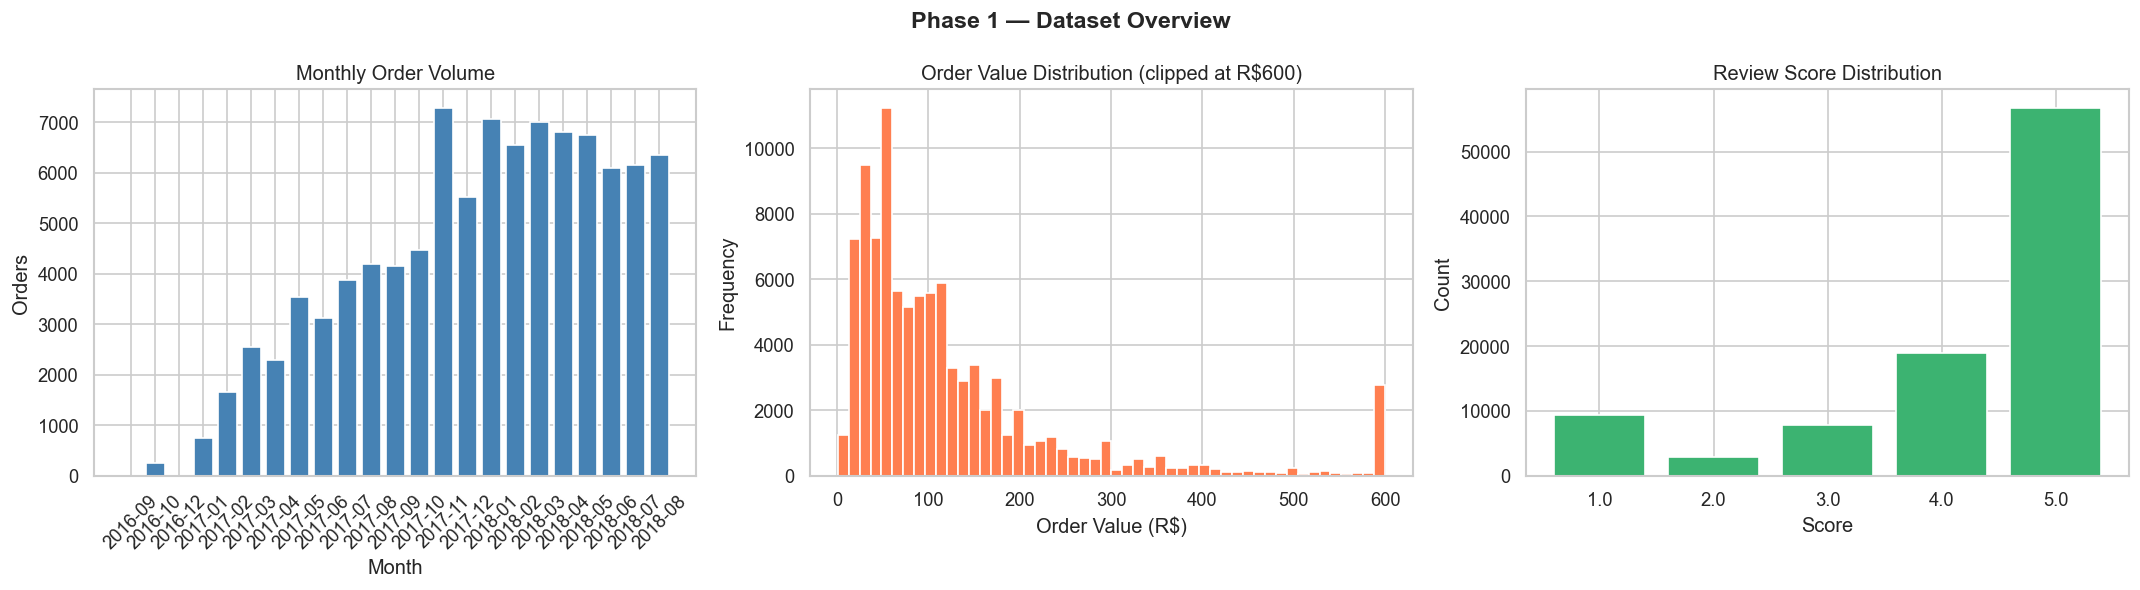

✅ Chart saved → phase1_overview.png


In [8]:
# ── 1.7  EXPLORATORY VISUALISATIONS ─────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 1 — Dataset Overview', fontsize=14, fontweight='bold')

# Monthly order volume
monthly = df_clean.groupby('order_month').size().reset_index(name='orders')
monthly['order_month'] = monthly['order_month'].astype(str)
axes[0].bar(monthly['order_month'], monthly['orders'], color='steelblue')
axes[0].set_title('Monthly Order Volume')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=45)

# Order value distribution
axes[1].hist(df_clean['total_item_value'].clip(upper=600), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Order Value Distribution (clipped at R$600)')
axes[1].set_xlabel('Order Value (R$)')
axes[1].set_ylabel('Frequency')

# Review score distribution
review_counts = df_clean['review_score'].value_counts().sort_index()
axes[2].bar(review_counts.index.astype(str), review_counts.values, color='mediumseagreen')
axes[2].set_title('Review Score Distribution')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('phase1_overview.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved → phase1_overview.png')

In [9]:
# ── 1.8  SAVE MASTER TABLE ───────────────────────────────────

df_clean.to_csv('master_table.csv', index=False)
print(f'✅ Saved → master_table.csv')
print(f'   Shape : {df_clean.shape}')
print(f'   Columns: {list(df_clean.columns)}')

✅ Saved → master_table.csv
   Shape : (96470, 28)
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'num_items', 'total_item_value', 'total_freight', 'num_sellers', 'total_payment', 'payment_installments', 'payment_type', 'review_score', 'main_category', 'delivery_days', 'delivery_delay_days', 'order_month', 'order_year', 'order_dayofweek', 'order_hour', 'total_order_value']


---
<a id='phase2'></a>
# 🎯 Phase 2 — RFM Analysis + Customer Segmentation

**Goal:** Score every customer on Recency, Frequency and Monetary value,  
then use K-Means clustering to identify actionable customer segments.

**Output:** Customer segment labels appended to master table.

In [10]:
# ── 2.1  LOAD DATA ───────────────────────────────────────────

df_clean = pd.read_csv('master_table.csv', parse_dates=['order_purchase_timestamp'])
SNAPSHOT_DATE = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Snapshot date (RFM reference): {SNAPSHOT_DATE.date()}')

Snapshot date (RFM reference): 2018-08-30


In [11]:
# ── 2.2  COMPUTE RFM METRICS ─────────────────────────────────

rfm = df_clean.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('total_payment', 'sum')
).reset_index()

print(f'✅ RFM table: {rfm.shape}')
rfm.describe()

✅ RFM table: (93350, 4)


,Recency,Frequency,Monetary
count,93350.00,93350.00,93350.00
mean,237.95,1.03,165.20
std,152.59,0.21,226.32
min,1.00,1.00,0.00
25%,114.00,1.00,63.05
50%,219.00,1.00,107.78
75%,346.00,1.00,182.55
max,714.00,15.00,13664.08


In [12]:
# ── 2.3  RFM SCORING (1–5 scale) ────────────────────────────
# Recency: lower is better → reverse rank
rfm['R_score'] = pd.qcut(rfm['Recency'],   q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_Score']  = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
rfm['RFM_Segment']= rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print('RFM Score Distribution:')
print(rfm['RFM_Score'].value_counts().sort_index())

RFM Score Distribution:
RFM_Score
3       799
4      2362
5      4692
6      7576
7     11084
8     13319
9     13986
10    13142
11    10896
12     7465
13     4590
14     2439
15     1000
Name: count, dtype: int64


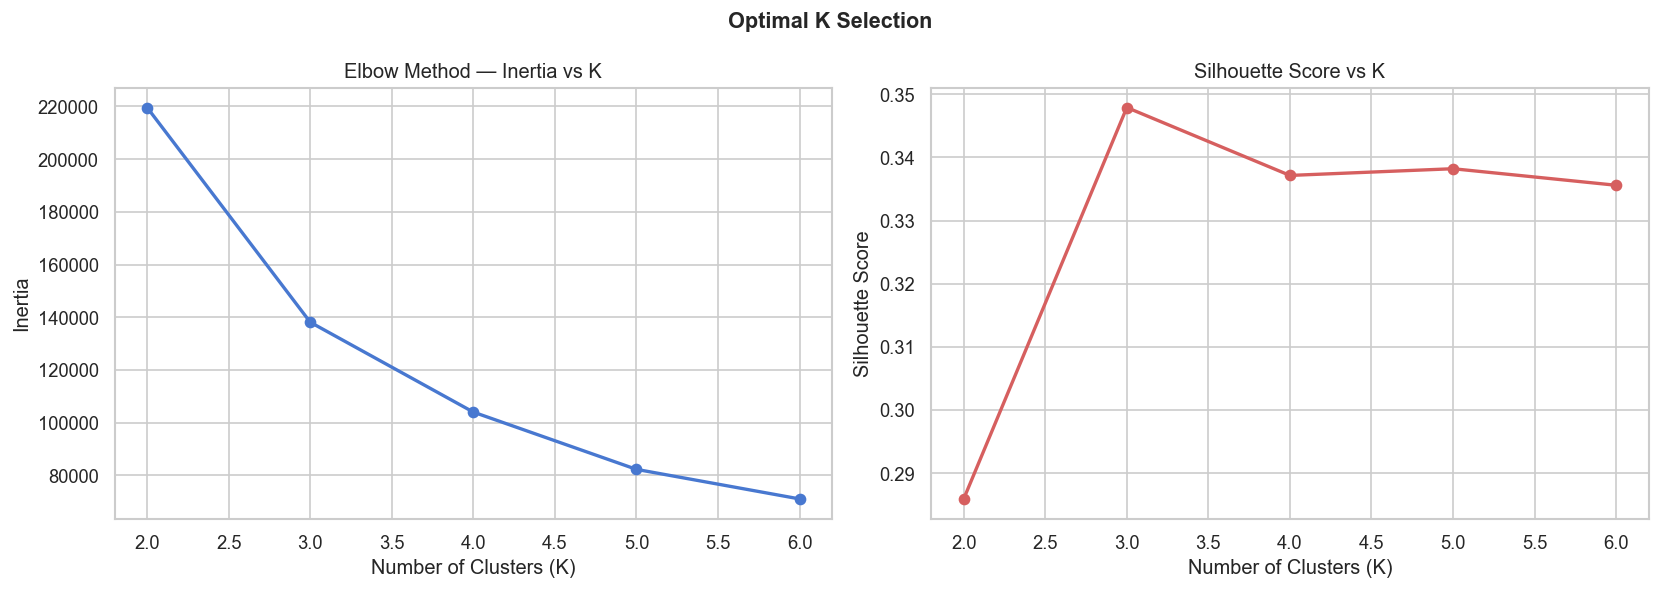

✅ Best silhouette score at K = 3


In [13]:
# ── 2.4  K-MEANS CLUSTERING ──────────────────────────────────

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Log-transform Monetary to reduce skew, then scale
rfm_scaled = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_scaled['Monetary'] = np.log1p(rfm_scaled['Monetary'])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(rfm_scaled)

# Sample 10K rows for silhouette score — enough to be accurate
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=10000, replace=False)
X_sample   = X_scaled[sample_idx]

# Elbow method
inertias, sil_scores = [], []
K_range = range(2, 7)

for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.set_title('Elbow Method — Inertia vs K')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')

ax2.plot(K_range, sil_scores, 'ro-', linewidth=2)
ax2.set_title('Silhouette Score vs K')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_elbow.png', bbox_inches='tight')
plt.show()
print('✅ Best silhouette score at K =', K_range[np.argmax(sil_scores)])

In [ ]:
# ── 2.5  FIT FINAL K-MEANS (K=4) ────────────────────────────

# Silhouette score suggested K=3, but K=4 is chosen for business interpretability.
# Four segments (Champions, Loyal, At Risk, Lost) provide more actionable insights
# for targeted marketing than three clusters would allow.

OPTIMAL_K = 4
km_final  = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = rfm.groupby('Cluster').agg(
    Customers = ('customer_unique_id', 'count'),
    Avg_Recency  = ('Recency',   'mean'),
    Avg_Frequency= ('Frequency', 'mean'),
    Avg_Monetary = ('Monetary',  'mean'),
    Avg_RFM_Score= ('RFM_Score', 'mean')
).round(2)

print('Cluster Profiles:')
print(cluster_profile)

Cluster Profiles:
         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Avg_RFM_Score
Cluster                                                                    
0            35715       147.61           1.00         69.15           8.67
1            27052       425.15           1.00        119.47           7.07
2            27782       173.59           1.00        318.74          10.96
3             2801       220.29           2.11        308.59          12.42


Segment distribution:
Segment_Label
Lost Customers     35715
Champions          27782
At Risk            27052
Loyal Customers     2801
Name: count, dtype: int64


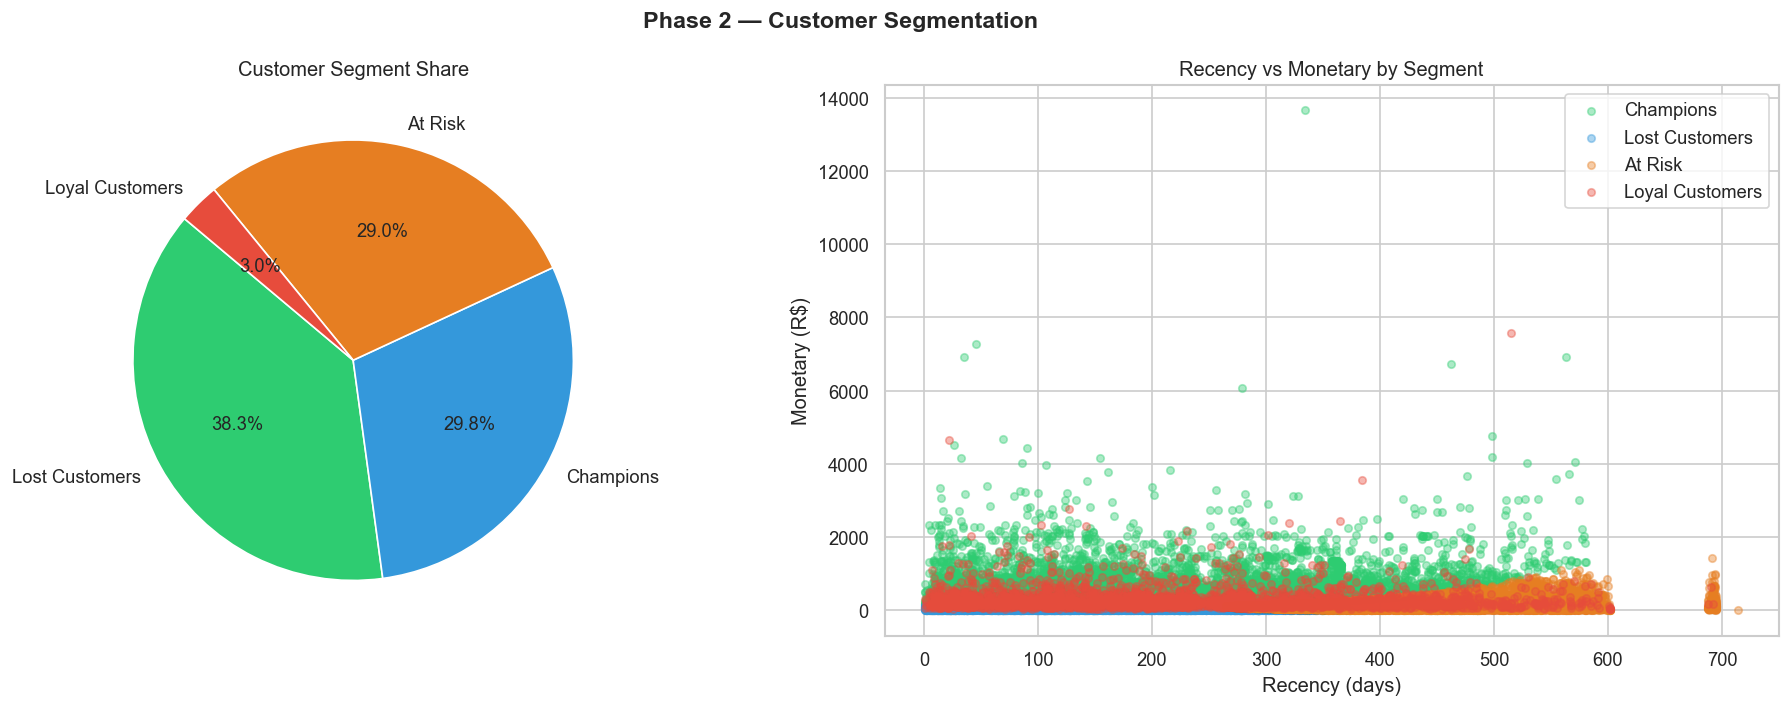

✅ Chart saved → outputs/phase2_segments.png


In [15]:
# ── 2.6  ASSIGN BUSINESS LABELS ─────────────────────────────
# Sort clusters by Avg_Monetary descending and assign labels

sorted_clusters = cluster_profile.sort_values('Avg_Monetary', ascending=False)
label_map = {}
business_labels = ['Champions', 'Loyal Customers', 'At Risk', 'Lost Customers']
for i, (cluster_id, _) in enumerate(sorted_clusters.iterrows()):
    label_map[cluster_id] = business_labels[i]

rfm['Segment_Label'] = rfm['Cluster'].map(label_map)

print('Segment distribution:')
print(rfm['Segment_Label'].value_counts())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 2 — Customer Segmentation', fontsize=14, fontweight='bold')

# Pie chart
seg_counts = rfm['Segment_Label'].value_counts()
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
axes[0].pie(seg_counts, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[0].set_title('Customer Segment Share')

# Scatter: Recency vs Monetary
palette = dict(zip(rfm['Segment_Label'].unique(), colors))
for label in rfm['Segment_Label'].unique():
    subset = rfm[rfm['Segment_Label'] == label]
    axes[1].scatter(subset['Recency'], subset['Monetary'],
                    alpha=0.4, label=label, s=20, color=palette.get(label, 'grey'))
axes[1].set_title('Recency vs Monetary by Segment')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary (R$)')
axes[1].legend()

plt.tight_layout()
plt.savefig('phase2_segments.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved → outputs/phase2_segments.png')

In [16]:
# ── 2.7  SAVE RFM TABLE ──────────────────────────────────────

rfm.to_csv('rfm_segments.csv', index=False)
print('✅ Saved → data/rfm_segments.csv')
rfm.head()

✅ Saved → data/rfm_segments.csv


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,RFM_Segment,Cluster,Segment_Label
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,9,414,2,Champions
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,6,411,0,Lost Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,4,112,1,At Risk
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,4,211,1,At Risk
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,7,214,2,Champions


---
<a id='phase3'></a>
# 🔮 Phase 3 — Churn Prediction (XGBoost + SHAP)

**Goal:** Identify customers at risk of churning using a classification model.  
Define churn as: no purchase in the last 180 days relative to snapshot date.  
Use SHAP values to explain what drives churn.

In [17]:
# ── 3.1  DEFINE CHURN LABEL ──────────────────────────────────

df_clean = pd.read_csv('master_table.csv', parse_dates=['order_purchase_timestamp'])
rfm      = pd.read_csv('rfm_segments.csv')

SNAPSHOT_DATE  = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
CHURN_THRESHOLD = 180  # days

rfm['churned'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)

print(f'Churn threshold : {CHURN_THRESHOLD} days')
print(f'Churned         : {rfm["churned"].sum():,} ({rfm["churned"].mean()*100:.1f}%)')
print(f'Not Churned     : {(1-rfm["churned"]).sum():,} ({(1-rfm["churned"]).mean()*100:.1f}%)')

Churn threshold : 180 days
Churned         : 55,250 (59.2%)
Not Churned     : 38,100 (40.8%)


In [18]:
# ── 3.2  ENGINEER CHURN FEATURES ────────────────────────────

# Aggregate customer-level features from master table
cust_features = df_clean.groupby('customer_unique_id').agg(
    avg_order_value    = ('total_payment', 'mean'),
    total_orders       = ('order_id', 'nunique'),
    avg_review_score   = ('review_score', 'mean'),
    avg_delivery_days  = ('delivery_days', 'mean'),
    avg_delay_days     = ('delivery_delay_days', 'mean'),
    avg_items_per_order= ('num_items', 'mean'),
    avg_freight        = ('total_freight', 'mean'),
    pct_late_deliveries= ('delivery_delay_days', lambda x: (x > 0).mean()),
    total_spent        = ('total_payment', 'sum'),
    num_categories     = ('main_category', 'nunique')
).reset_index()

# Merge with RFM
churn_df = rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary',
                'RFM_Score', 'churned']].merge(cust_features, on='customer_unique_id', how='left')

churn_df.fillna(churn_df.median(numeric_only=True), inplace=True)
print(f'✅ Churn feature matrix: {churn_df.shape}')
churn_df.head(3)

✅ Churn feature matrix: (93350, 16)


,customer_unique_id,Recency,Frequency,Monetary,RFM_Score,churned,avg_order_value,total_orders,avg_review_score,avg_delivery_days,avg_delay_days,avg_items_per_order,avg_freight,pct_late_deliveries,total_spent,num_categories
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,9,0,141.90,1,5.00,6.00,-5.00,1.00,12.00,0.00,141.90,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,6,0,27.19,1,4.00,3.00,-5.00,1.00,8.29,0.00,27.19,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,1,86.22,1,3.00,25.00,-2.00,1.00,17.22,0.00,86.22,1


In [19]:
# ── 3.3  TRAIN / TEST SPLIT ──────────────────────────────────

FEATURES = ['Recency', 'Frequency', 'Monetary', 'RFM_Score',
            'avg_order_value', 'total_orders', 'avg_review_score',
            'avg_delivery_days', 'avg_delay_days', 'avg_items_per_order',
            'avg_freight', 'pct_late_deliveries', 'total_spent', 'num_categories']

X = churn_df[FEATURES]
y = churn_df['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f} | Test churn rate: {y_test.mean():.3f}')

Train: (74680, 14) | Test: (18670, 14)
Train churn rate: 0.592 | Test churn rate: 0.592


In [20]:
# ── 3.4  TRAIN XGBOOST MODEL ────────────────────────────────

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators     = 300,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos,
    random_state     = 42,
    eval_metric      = 'auc',
    use_label_encoder= False
)

xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

y_pred_proba = xgb.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f'\n✅ XGBoost trained')
print(f'   ROC-AUC : {roc_auc:.4f}')
print(f'\n{classification_report(y_test, y_pred)}')


✅ XGBoost trained
   ROC-AUC : 1.0000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7620
           1       1.00      1.00      1.00     11050

    accuracy                           1.00     18670
   macro avg       1.00      1.00      1.00     18670
weighted avg       1.00      1.00      1.00     18670



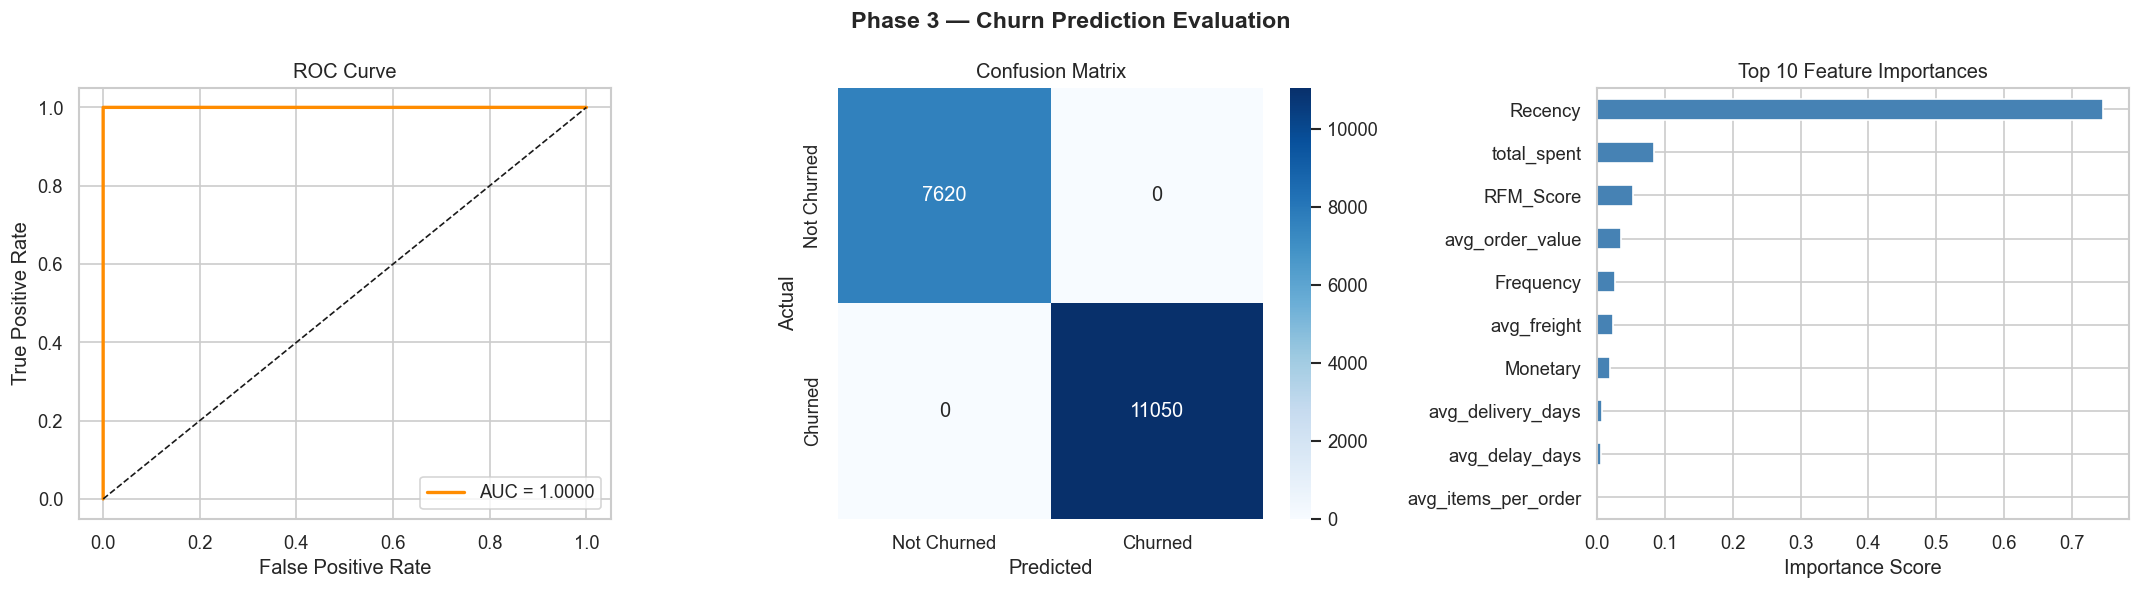

✅ Chart saved → outputs/phase3_churn_eval.png


In [21]:
# ── 3.5  EVALUATION PLOTS ────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 3 — Churn Prediction Evaluation', fontsize=14, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title('ROC Curve')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Feature Importance
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
feat_imp.tail(10).plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Top 10 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('phase3_churn_eval.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved → outputs/phase3_churn_eval.png')

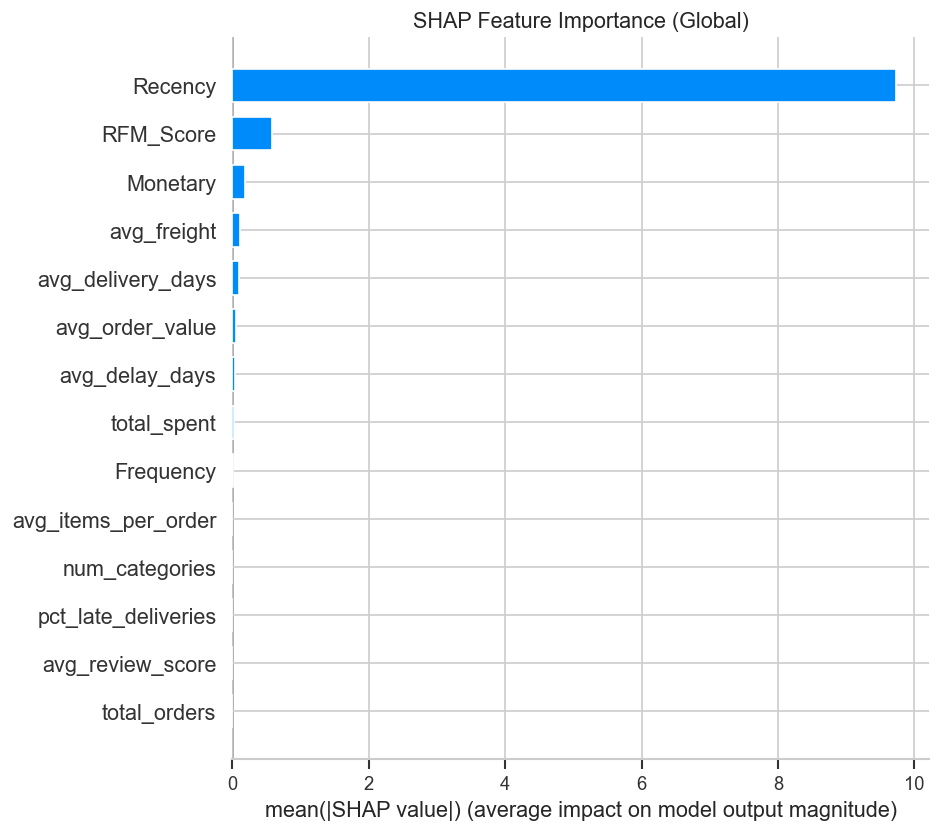

✅ SHAP chart saved → outputs/phase3_shap_bar.png


In [22]:
# ── 3.6  SHAP EXPLAINABILITY ─────────────────────────────────

explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Global)', fontsize=13)
plt.tight_layout()
plt.savefig('phase3_shap_bar.png', bbox_inches='tight')
plt.show()
print('✅ SHAP chart saved → outputs/phase3_shap_bar.png')

In [23]:
# ── 3.7  SAVE CHURN PREDICTIONS ─────────────────────────────

churn_df['churn_probability'] = xgb.predict_proba(X)[:, 1]
churn_df['churn_predicted']   = (churn_df['churn_probability'] >= 0.5).astype(int)
churn_df.to_csv('churn_predictions.csv', index=False)
print('✅ Saved → data/churn_predictions.csv')

✅ Saved → data/churn_predictions.csv


---
<a id='phase4'></a>
# 💰 Phase 4 — Customer Lifetime Value (CLV) Forecasting

**Goal:** Predict the long-term revenue value of each customer  
using a regression-based CLV model and segment customers by predicted value.

In [24]:
# ── 4.1  COMPUTE HISTORICAL CLV ──────────────────────────────

from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

df_clean = pd.read_csv('master_table.csv', parse_dates=['order_purchase_timestamp'])
rfm      = pd.read_csv('rfm_segments.csv')

# Historical CLV = total spend per customer
clv_hist = df_clean.groupby('customer_unique_id').agg(
    historical_clv     = ('total_payment', 'sum'),
    first_order        = ('order_purchase_timestamp', 'min'),
    last_order         = ('order_purchase_timestamp', 'max'),
    total_orders       = ('order_id', 'nunique'),
    avg_order_value    = ('total_payment', 'mean'),
    avg_review_score   = ('review_score', 'mean'),
    avg_delivery_days  = ('delivery_days', 'mean'),
    num_categories     = ('main_category', 'nunique')
).reset_index()

SNAPSHOT_DATE = df_clean['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
clv_hist['customer_tenure_days'] = (SNAPSHOT_DATE - clv_hist['first_order']).dt.days

# Merge with RFM
clv_df = clv_hist.merge(
    rfm[['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'RFM_Score', 'Segment_Label']],
    on='customer_unique_id', how='left'
)
clv_df.fillna(clv_df.median(numeric_only=True), inplace=True)
print(f'✅ CLV dataset: {clv_df.shape}')
clv_df[['historical_clv', 'total_orders', 'customer_tenure_days']].describe()

✅ CLV dataset: (93350, 15)


,historical_clv,total_orders,customer_tenure_days
count,93350.00,93350.00,93350.00
mean,165.20,1.03,240.60
std,226.32,0.21,153.10
min,0.00,1.00,1.00
25%,63.05,1.00,117.00
50%,107.78,1.00,222.00
75%,182.55,1.00,350.00
max,13664.08,15.00,714.00


In [25]:
# ── 4.2  TRAIN CLV REGRESSION MODEL ─────────────────────────

CLV_FEATURES = ['Recency', 'Frequency', 'RFM_Score', 'avg_order_value',
                'total_orders', 'avg_review_score', 'avg_delivery_days',
                'num_categories', 'customer_tenure_days']

X_clv = clv_df[CLV_FEATURES]
y_clv = np.log1p(clv_df['historical_clv'])  # log-transform target

X_tr, X_te, y_tr, y_te = train_test_split(X_clv, y_clv, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                  learning_rate=0.05, random_state=42)
gbr.fit(X_tr, y_tr)

y_pred_clv = gbr.predict(X_te)
mae   = mean_absolute_error(np.expm1(y_te), np.expm1(y_pred_clv))
r2    = r2_score(y_te, y_pred_clv)

print(f'✅ CLV Model trained')
print(f'   MAE (original scale): R$ {mae:.2f}')
print(f'   R² Score            : {r2:.4f}')

✅ CLV Model trained
   MAE (original scale): R$ 1.34
   R² Score            : 0.9998


In [26]:
# ── 4.3  PREDICT CLV & SEGMENT ──────────────────────────────

clv_df['predicted_clv'] = np.expm1(gbr.predict(X_clv))
clv_df['clv_tier'] = pd.qcut(
    clv_df['predicted_clv'], q=3,
    labels=['Low Value', 'Mid Value', 'High Value']
)

print('CLV Tier Distribution:')
print(clv_df['clv_tier'].value_counts())
print('\nAvg Predicted CLV by Tier:')
print(clv_df.groupby('clv_tier')['predicted_clv'].mean().round(2))

CLV Tier Distribution:
clv_tier
Low Value     31251
High Value    31104
Mid Value     30995
Name: count, dtype: int64

Avg Predicted CLV by Tier:
clv_tier
Low Value     50.02
Mid Value    109.83
High Value   335.63
Name: predicted_clv, dtype: float64


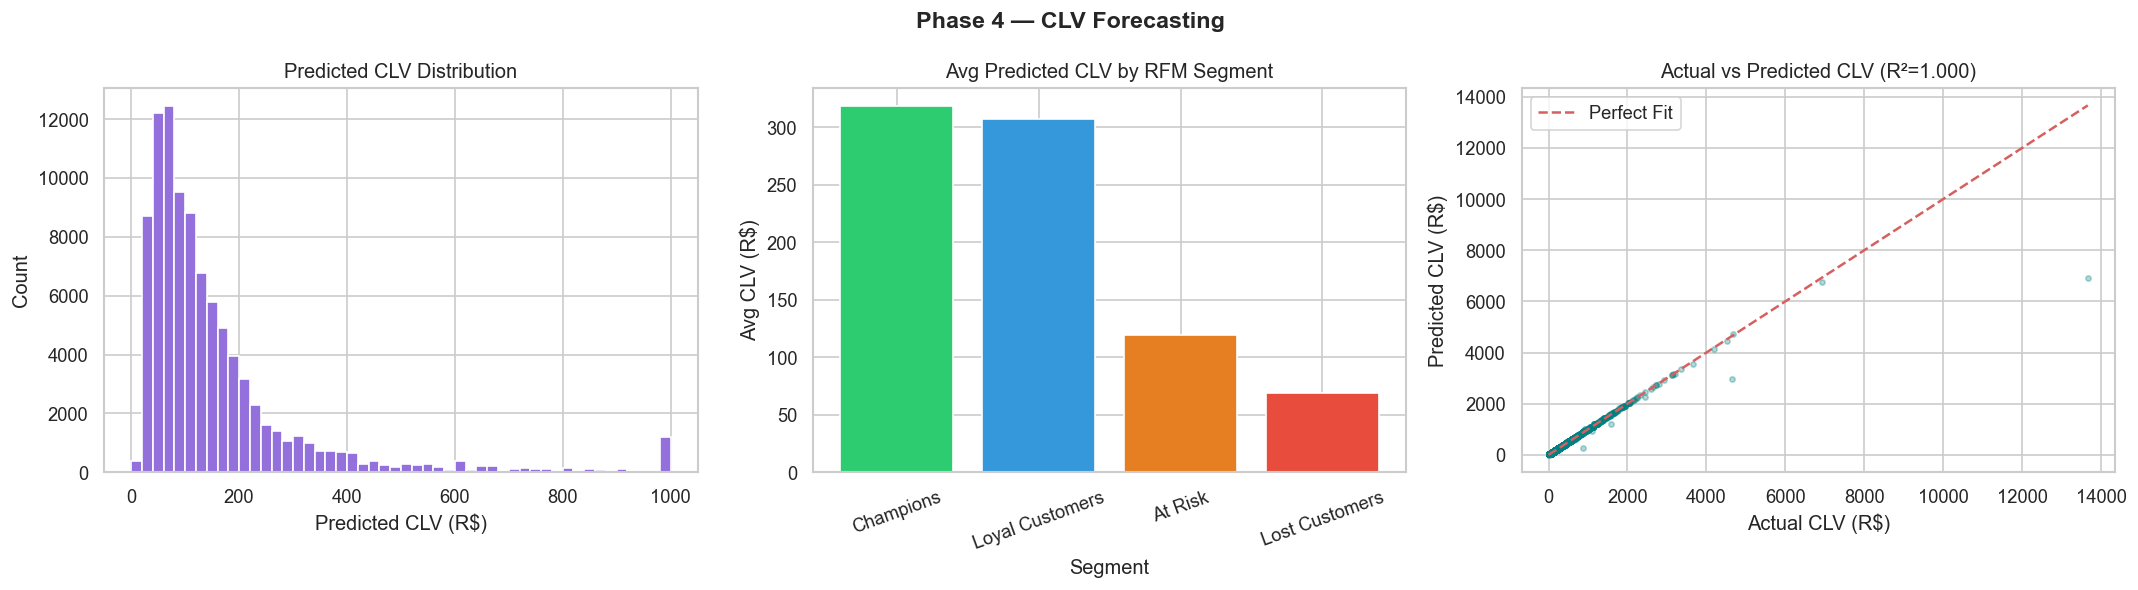

✅ Chart saved → outputs/phase4_clv.png


In [27]:
# ── 4.4  CLV VISUALISATIONS ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 4 — CLV Forecasting', fontsize=14, fontweight='bold')

# CLV distribution
axes[0].hist(clv_df['predicted_clv'].clip(upper=1000), bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Predicted CLV Distribution')
axes[0].set_xlabel('Predicted CLV (R$)')
axes[0].set_ylabel('Count')

# CLV by segment
seg_clv = clv_df.groupby('Segment_Label')['predicted_clv'].mean().sort_values(ascending=False)
axes[1].bar(seg_clv.index, seg_clv.values, color=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'])
axes[1].set_title('Avg Predicted CLV by RFM Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Avg CLV (R$)')
axes[1].tick_params(axis='x', rotation=20)

# Actual vs Predicted
axes[2].scatter(np.expm1(y_te), np.expm1(y_pred_clv), alpha=0.3, s=10, color='teal')
max_val = max(np.expm1(y_te).max(), np.expm1(y_pred_clv).max())
axes[2].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
axes[2].set_title(f'Actual vs Predicted CLV (R²={r2:.3f})')
axes[2].set_xlabel('Actual CLV (R$)')
axes[2].set_ylabel('Predicted CLV (R$)')
axes[2].legend()

plt.tight_layout()
plt.savefig('phase4_clv.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved → outputs/phase4_clv.png')

In [28]:
# ── 4.5  SAVE CLV TABLE ──────────────────────────────────────

clv_df.to_csv('clv_predictions.csv', index=False)
print('✅ Saved → clv_predictions.csv')

✅ Saved → clv_predictions.csv


---
<a id='phase5'></a>
# 🛍️ Phase 5 — Market Basket Analysis (Apriori)

**Goal:** Discover which product categories are frequently bought together,  
and surface high-confidence association rules for cross-sell recommendations.

In [29]:
# ── 5.1  BUILD ORDER-CATEGORY MATRIX ────────────────────────

df_clean = pd.read_csv('master_table.csv')

# Get order-level items with translated category names
items_cat = order_items.merge(
    products[['product_id', 'product_category_name']], on='product_id', how='left'
).merge(category_transl, on='product_category_name', how='left')

# Keep only delivered orders
delivered_orders = df_clean['order_id'].unique()
items_cat = items_cat[items_cat['order_id'].isin(delivered_orders)]
items_cat.dropna(subset=['product_category_name_english'], inplace=True)

# Build basket: one row per order, columns = categories
basket = items_cat.groupby(['order_id', 'product_category_name_english'])['order_item_id']\
                  .count().unstack(fill_value=0)
basket = (basket > 0).astype(bool)  # convert to boolean

# Filter orders with at least 2 categories (multi-category orders only)
basket = basket[basket.sum(axis=1) >= 2]

print(f'✅ Basket matrix: {basket.shape}')
print(f'   Multi-category orders: {len(basket):,}')

✅ Basket matrix: (722, 71)
   Multi-category orders: 722


In [30]:
# ── 5.2  APRIORI — FREQUENT ITEMSETS ────────────────────────

frequent_itemsets = apriori(
    basket,
    min_support    = 0.01,   # at least 1% of multi-category orders
    use_colnames   = True,
    max_len        = 3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'✅ Frequent itemsets found: {len(frequent_itemsets):,}')
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

✅ Frequent itemsets found: 48
    support                           itemsets  length
13     0.28                  (furniture_decor)       1
2      0.27                   (bed_bath_table)       1
19     0.14                       (housewares)       1
1      0.13                             (baby)       1
15     0.10                     (garden_tools)       1
35     0.10  (bed_bath_table, furniture_decor)       2
16     0.10                    (health_beauty)       1
25     0.09                   (sports_leisure)       1
7      0.09                       (cool_stuff)       1
3      0.07            (computers_accessories)       1


In [31]:
# ── 5.3  ASSOCIATION RULES ───────────────────────────────────

rules = association_rules(
    frequent_itemsets,
    metric     = 'lift',
    min_threshold = 1.2
)
rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

rules_sorted = rules.sort_values('lift', ascending=False)
print(f'✅ Association rules: {len(rules_sorted):,}')
print('\nTop 10 rules by Lift:')
print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10).to_string(index=False))

✅ Association rules: 18

Top 10 rules by Lift:
   antecedents    consequents  support  confidence  lift
     perfumery  health_beauty     0.02        0.44  4.60
 health_beauty      perfumery     0.02        0.16  4.60
  home_confort bed_bath_table     0.06        0.86  3.15
bed_bath_table   home_confort     0.06        0.22  3.15
          baby           toys     0.03        0.20  2.95
          toys           baby     0.03        0.38  2.95
          baby     cool_stuff     0.03        0.22  2.39
    cool_stuff           baby     0.03        0.31  2.39
 health_beauty sports_leisure     0.02        0.20  2.19
sports_leisure  health_beauty     0.02        0.21  2.19


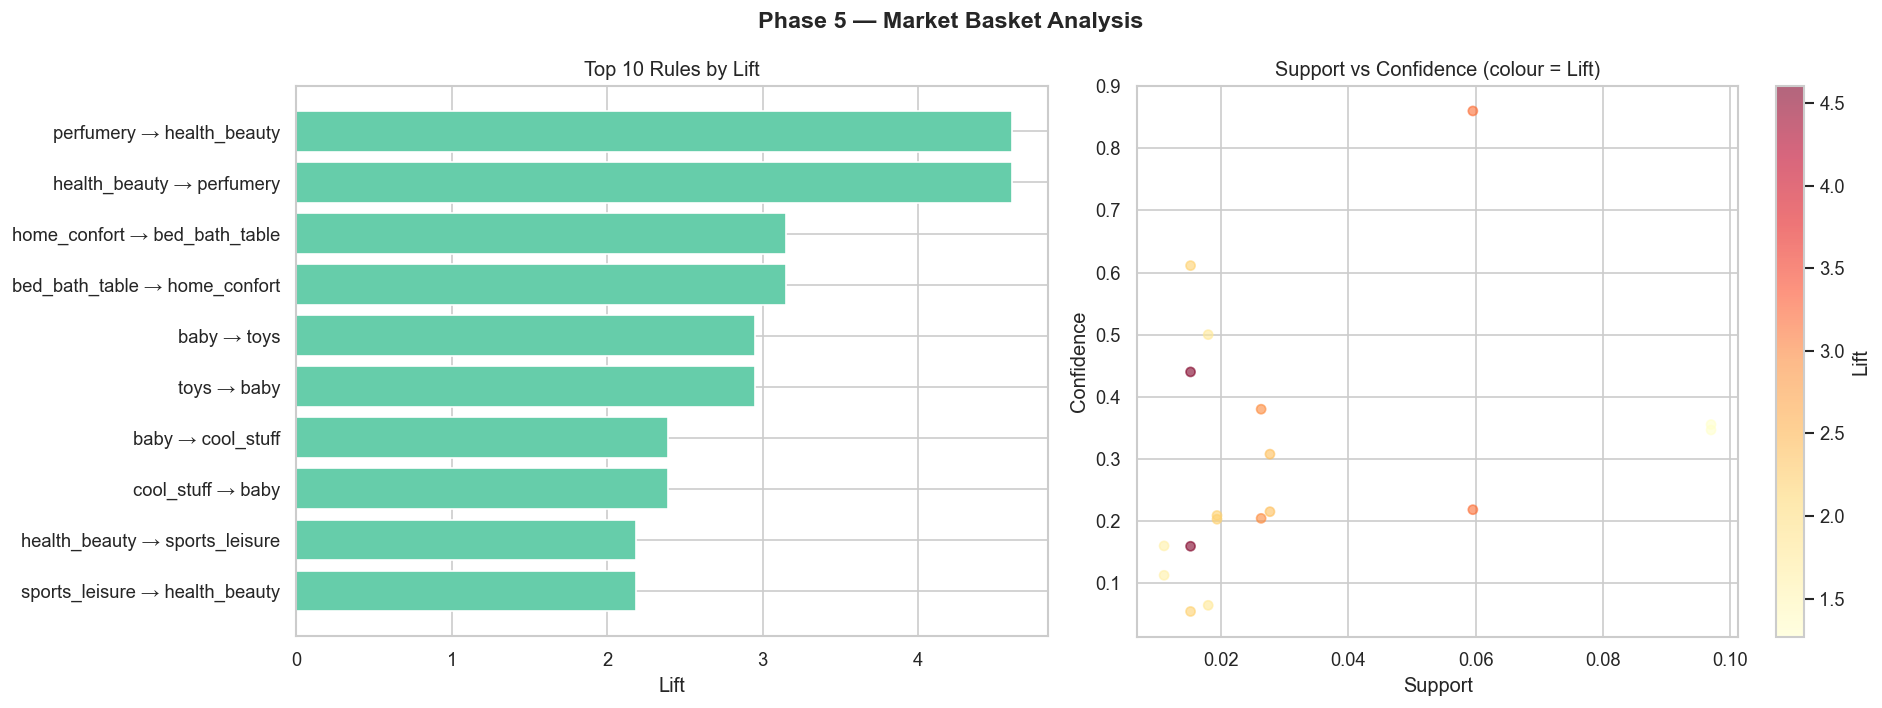

✅ Chart saved → outputs/phase5_market_basket.png


In [32]:
# ── 5.4  VISUALISE TOP RULES ─────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 5 — Market Basket Analysis', fontsize=14, fontweight='bold')

# Top rules by lift
top_rules = rules_sorted.head(10).copy()
top_rules['rule'] = top_rules['antecedents'] + ' → ' + top_rules['consequents']
axes[0].barh(top_rules['rule'], top_rules['lift'], color='mediumaquamarine')
axes[0].set_title('Top 10 Rules by Lift')
axes[0].set_xlabel('Lift')
axes[0].invert_yaxis()

# Support vs Confidence scatter
sc = axes[1].scatter(
    rules_sorted['support'],
    rules_sorted['confidence'],
    c=rules_sorted['lift'],
    cmap='YlOrRd',
    alpha=0.6, s=30
)
plt.colorbar(sc, ax=axes[1], label='Lift')
axes[1].set_title('Support vs Confidence (colour = Lift)')
axes[1].set_xlabel('Support')
axes[1].set_ylabel('Confidence')

plt.tight_layout()
plt.savefig('phase5_market_basket.png', bbox_inches='tight')
plt.show()
print('✅ Chart saved → outputs/phase5_market_basket.png')

In [33]:
# ── 5.5  SAVE RULES ──────────────────────────────────────────

rules_sorted.to_csv('association_rules.csv', index=False)
print('✅ Saved → data/association_rules.csv')

print('\n' + '='*60)
print('🏁 ALL 5 PHASES COMPLETE')
print('='*60)
print('Outputs:')
print('  data/master_table.csv')
print('  data/rfm_segments.csv')
print('  data/churn_predictions.csv')
print('  data/clv_predictions.csv')
print('  data/association_rules.csv')
print('\nNext: Open powerbi/ecommerce_dashboard.pbix')

✅ Saved → data/association_rules.csv

🏁 ALL 5 PHASES COMPLETE
Outputs:
  data/master_table.csv
  data/rfm_segments.csv
  data/churn_predictions.csv
  data/clv_predictions.csv
  data/association_rules.csv

Next: Open powerbi/ecommerce_dashboard.pbix
